# Network Analysis Agent - Clean Implementation

**Purpose**: Detect suspicious accounts using network topology analysis (excluding transaction volume features)

**Approach**:
- Build transaction network graph
- Extract network topology features (centrality, clustering, community)
- Label high-volume accounts as suspicious (proxy for anomalies)
- Train models using **network structure only** (no volume features)

**Key Decision**: We exclude transaction count/amount features to avoid circular reasoning and achieve realistic model performance.

---

## 1. Setup & Configuration

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from datetime import datetime
import warnings
import time
import pickle
import json

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, 
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)

# Models
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression

# Imbalanced learning
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [2]:
# Configuration
CONFIG = {
    # Data
    'data_path': '../../transaction_pattern_agent/data/Anti Money Laundering Transaction Data (SAML-D).csv',
    
    # Network Construction
    'top_n_accounts': 5000,  # Focus on most active accounts
    'min_transactions': 5,    # Minimum transactions per account
    
    # Labeling Strategy
    'suspicious_percentile': 90,  # Top 10% by volume = suspicious
    
    # Model Training
    'test_size': 0.2,
    'random_state': 42,
    'use_smote': True,
    'smote_k_neighbors': 5,
    
    # Output
    'model_output_dir': '../trained_models/',
}

print("✅ Configuration loaded")
print(f"   Network size: Top {CONFIG['top_n_accounts']:,} accounts")
print(f"   Labeling: Top {100-CONFIG['suspicious_percentile']}% volume as suspicious")

✅ Configuration loaded
   Network size: Top 5,000 accounts
   Labeling: Top 10% volume as suspicious


## 2. Load Data

In [3]:
# Load transaction data
df = pd.read_csv(CONFIG['data_path'])

print(f"📊 Dataset loaded: {len(df):,} transactions")
print(f"   Columns: {', '.join(df.columns)}")
print(f"\\n   Shape: {df.shape}")

# Auto-detect column names with flexible patterns
from_col = next((col for col in df.columns if any(p in col.lower() for p in ['sender', 'from'])), None)
to_col = next((col for col in df.columns if any(p in col.lower() for p in ['receiver', 'to', 'recipient'])), None)
amount_col = next((col for col in df.columns if 'amount' in col.lower()), None)
timestamp_col = next((col for col in df.columns if any(p in col.lower() for p in ['timestamp', 'time', 'date'])), None)

print(f"\\n✅ Column mapping:")
print(f"   From: {from_col}")
print(f"   To: {to_col}")
print(f"   Amount: {amount_col}")
print(f"   Timestamp: {timestamp_col}")

📊 Dataset loaded: 9,504,852 transactions
   Columns: Time, Date, Sender_account, Receiver_account, Amount, Payment_currency, Received_currency, Sender_bank_location, Receiver_bank_location, Payment_type, Is_laundering, Laundering_type
\n   Shape: (9504852, 12)
\n✅ Column mapping:
   From: Sender_account
   To: Receiver_account
   Amount: Amount
   Timestamp: Time


## 3. Build Transaction Network

In [4]:
# Identify most active accounts
account_activity = pd.concat([
    df[from_col].value_counts(),
    df[to_col].value_counts()
]).groupby(level=0).sum().sort_values(ascending=False)

top_accounts = set(account_activity.head(CONFIG['top_n_accounts']).index)

# Filter to transactions where EITHER sender OR receiver is in top accounts
df_network = df[
    (df[from_col].isin(top_accounts)) | 
    (df[to_col].isin(top_accounts))
].copy()

print(f"🔗 Network construction:")
print(f"   Top accounts selected: {len(top_accounts):,}")
print(f"   Transactions in network: {len(df_network):,}")
print(f"   Coverage: {len(df_network)/len(df)*100:.1f}% of original data")

🔗 Network construction:
   Top accounts selected: 5,000
   Transactions in network: 3,717,875
   Coverage: 39.1% of original data


In [5]:
# Build directed graph
G = nx.DiGraph()

# Add edges with aggregated attributes
edge_data = df_network.groupby([from_col, to_col]).agg({
    amount_col: ['sum', 'mean', 'count']
}).reset_index()

edge_data.columns = ['from', 'to', 'total_amount', 'avg_amount', 'count']

for _, row in edge_data.iterrows():
    G.add_edge(
        row['from'], 
        row['to'],
        weight=row['total_amount'],
        count=row['count'],
        avg_amount=row['avg_amount']
    )

print(f"\n✅ Graph built:")
print(f"   Nodes (accounts): {G.number_of_nodes():,}")
print(f"   Edges (connections): {G.number_of_edges():,}")
print(f"   Density: {nx.density(G):.6f}")


✅ Graph built:
   Nodes (accounts): 289,826
   Edges (connections): 301,835
   Density: 0.000004


## 4. Extract Network Topology Features

**Important**: We extract **only network structure features**, excluding transaction volumes/amounts to avoid circular reasoning.

In [6]:
print("🔍 Computing network topology features...\n")

# Degree metrics
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

# Centrality metrics
print("   Computing centrality metrics...")
degree_centrality = nx.degree_centrality(G)
in_degree_centrality = nx.in_degree_centrality(G)
out_degree_centrality = nx.out_degree_centrality(G)
betweenness = nx.betweenness_centrality(G, k=min(1000, G.number_of_nodes()))
closeness = nx.closeness_centrality(G)
pagerank = nx.pagerank(G, max_iter=100)

# Clustering
print("   Computing clustering coefficients...")
G_undirected = G.to_undirected()
clustering = nx.clustering(G_undirected)

# Eigenvector centrality (with error handling)
print("   Computing eigenvector centrality...")
try:
    eigenvector = nx.eigenvector_centrality(G, max_iter=1000)
except:
    eigenvector = {node: 0 for node in G.nodes()}
    print("      (Using zeros - convergence issue)")

# Community detection
print("   Detecting communities...")
from networkx.algorithms import community
if G_undirected.number_of_nodes() > 0:
    communities = list(community.greedy_modularity_communities(G_undirected))
    node_community = {}
    for i, comm in enumerate(communities):
        for node in comm:
            node_community[node] = i
else:
    communities = []
    node_community = {}

print(f"\\n✅ Features computed:")
print(f"   Communities detected: {len(communities)}")
print(f"   Features per node: 11 (all topology-based)")

🔍 Computing network topology features...

   Computing centrality metrics...
   Computing clustering coefficients...
   Computing clustering coefficients...
   Computing eigenvector centrality...
   Computing eigenvector centrality...
   Detecting communities...
   Detecting communities...
\n✅ Features computed:
   Communities detected: 5000
   Features per node: 11 (all topology-based)
\n✅ Features computed:
   Communities detected: 5000
   Features per node: 11 (all topology-based)


In [7]:
# Build feature dataframe - TOPOLOGY ONLY
features = []

for node in G.nodes():
    features.append({
        'account': node,
        # Degree
        'in_degree': in_degree[node],
        'out_degree': out_degree[node],
        # Centrality
        'degree_centrality': degree_centrality[node],
        'in_degree_centrality': in_degree_centrality[node],
        'out_degree_centrality': out_degree_centrality[node],
        'betweenness_centrality': betweenness[node],
        'closeness_centrality': closeness[node],
        'pagerank': pagerank[node],
        'eigenvector_centrality': eigenvector[node],
        # Clustering
        'clustering_coefficient': clustering[node],
        # Community
        'community': node_community[node],
    })

df_features = pd.DataFrame(features)

print(f"📊 Feature matrix created:")
print(f"   Shape: {df_features.shape}")
print(f"   Features: {df_features.columns.tolist()[1:]}")
print(f"\n⚠️  Note: Transaction volume/amount features EXCLUDED to prevent circular reasoning")

📊 Feature matrix created:
   Shape: (289826, 12)
   Features: ['in_degree', 'out_degree', 'degree_centrality', 'in_degree_centrality', 'out_degree_centrality', 'betweenness_centrality', 'closeness_centrality', 'pagerank', 'eigenvector_centrality', 'clustering_coefficient', 'community']

⚠️  Note: Transaction volume/amount features EXCLUDED to prevent circular reasoning


## 5. Create Labels

**Strategy**: Label accounts with high transaction volume as "suspicious" (proxy for anomalies)

**Note**: This creates a volume-based label, but our model will predict it using only network topology.

In [8]:
# Calculate transaction volumes per account
account_volumes = pd.concat([
    df_network.groupby(from_col).size().rename('sent'),
    df_network.groupby(to_col).size().rename('received')
], axis=1).fillna(0)

account_volumes['total_transactions'] = account_volumes['sent'] + account_volumes['received']
account_volumes = account_volumes.reset_index().rename(columns={'index': 'account'})

# Filter by minimum transactions
account_volumes = account_volumes[
    account_volumes['total_transactions'] >= CONFIG['min_transactions']
]

# Label top percentile as suspicious
threshold = account_volumes['total_transactions'].quantile(
    CONFIG['suspicious_percentile'] / 100
)

account_volumes['is_suspicious'] = (
    account_volumes['total_transactions'] >= threshold
).astype(int)

print(f"🏷️  Labeling strategy:")
print(f"   Min transactions: {CONFIG['min_transactions']}")
print(f"   Volume threshold: {threshold:.0f} transactions")
print(f"   Accounts analyzed: {len(account_volumes):,}")
print(f"\n📊 Label distribution:")
print(account_volumes['is_suspicious'].value_counts())
print(f"\n   Suspicious: {account_volumes['is_suspicious'].sum():,} ({account_volumes['is_suspicious'].mean()*100:.1f}%)")
print(f"   Normal: {(account_volumes['is_suspicious']==0).sum():,} ({(account_volumes['is_suspicious']==0).mean()*100:.1f}%)")

🏷️  Labeling strategy:
   Min transactions: 5
   Volume threshold: 18 transactions
   Accounts analyzed: 262,213

📊 Label distribution:
is_suspicious
0    230814
1     31399
Name: count, dtype: int64

   Suspicious: 31,399 (12.0%)
   Normal: 230,814 (88.0%)


## 6. Prepare Training Data

In [9]:
# Merge features with labels
df_model = df_features.merge(
    account_volumes[['account', 'is_suspicious']], 
    on='account', 
    how='inner'
)

print(f"✅ Training data prepared:")
print(f"   Total accounts: {len(df_model):,}")
print(f"   Features: {len(df_model.columns) - 2} (account + label excluded)")
print(f"   Class balance: {df_model['is_suspicious'].value_counts(normalize=True).to_dict()}")

✅ Training data prepared:
   Total accounts: 262,213
   Features: 11 (account + label excluded)
   Class balance: {0: 0.8802538394358784, 1: 0.11974616056412153}


In [10]:
# Split features and target
feature_cols = [col for col in df_model.columns if col not in ['account', 'is_suspicious']]

X = df_model[feature_cols]
y = df_model['is_suspicious']

print(f"📐 Feature matrix: {X.shape}")
print(f"🎯 Target vector: {y.shape}")
print(f"\n📋 Features used:")
for i, col in enumerate(feature_cols, 1):
    print(f"   {i:2d}. {col}")

📐 Feature matrix: (262213, 11)
🎯 Target vector: (262213,)

📋 Features used:
    1. in_degree
    2. out_degree
    3. degree_centrality
    4. in_degree_centrality
    5. out_degree_centrality
    6. betweenness_centrality
    7. closeness_centrality
    8. pagerank
    9. eigenvector_centrality
   10. clustering_coefficient
   11. community


In [11]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=CONFIG['test_size'],
    random_state=CONFIG['random_state'],
    stratify=y
)

print(f"✂️  Train/test split:")
print(f"   Train: {X_train.shape} - Suspicious: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"   Test:  {X_test.shape} - Suspicious: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

✂️  Train/test split:
   Train: (209770, 11) - Suspicious: 25119 (12.0%)
   Test:  (52443, 11) - Suspicious: 6280 (12.0%)


In [12]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📏 Feature scaling applied")
print(f"   Mean: {X_train_scaled.mean(axis=0)[:3]} ...")
print(f"   Std:  {X_train_scaled.std(axis=0)[:3]} ...")

📏 Feature scaling applied
   Mean: [ 2.61834168e-17 -6.57125856e-18  6.95740468e-17] ...
   Std:  [1. 1. 1.] ...


In [13]:
# Apply SMOTE to balance classes
if CONFIG['use_smote']:
    smote = SMOTE(
        k_neighbors=CONFIG['smote_k_neighbors'],
        random_state=CONFIG['random_state']
    )
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
    
    print(f"⚖️  SMOTE applied:")
    print(f"   Before: {y_train.value_counts().to_dict()}")
    print(f"   After:  {pd.Series(y_train_balanced).value_counts().to_dict()}")
else:
    X_train_balanced = X_train_scaled
    y_train_balanced = y_train
    print(f"⚖️  SMOTE skipped (use_smote=False)")

⚖️  SMOTE applied:
   Before: {0: 184651, 1: 25119}
   After:  {1: 184651, 0: 184651}


## 7. Train Models

In [14]:
# Define models
models = {
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=CONFIG['random_state'],
        eval_metric='logloss'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=CONFIG['random_state'],
        n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=CONFIG['random_state'],
        verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        random_state=CONFIG['random_state'],
        verbose=False
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=CONFIG['random_state'],
        n_jobs=-1
    )
}

print(f"🤖 Models configured: {len(models)}")

🤖 Models configured: 5


In [15]:
# Train and evaluate all models
results = []

print("🚀 Training models...\n")
print("="*80)

for name, model in models.items():
    print(f"\n📊 {name}")
    
    # Train
    start = time.time()
    model.fit(X_train_balanced, y_train_balanced)
    train_time = time.time() - start
    
    # Predict
    start = time.time()
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    infer_time = time.time() - start
    
    # Metrics
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Train Time (s)': train_time,
        'Inference Time (s)': infer_time
    })
    
    print(f"   ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f} | F1: {f1:.4f}")
    print(f"   Training: {train_time:.2f}s | Inference: {infer_time:.4f}s")

print("\n" + "="*80)
print("✅ All models trained\n")

# Results summary
df_results = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print("📊 Model Comparison:")
print(df_results.to_string(index=False))

🚀 Training models...


📊 XGBoost
   ROC-AUC: 0.8454 | PR-AUC: 0.5972 | F1: 0.4231
   Training: 0.63s | Inference: 0.0274s

📊 Random Forest
   ROC-AUC: 0.8454 | PR-AUC: 0.5972 | F1: 0.4231
   Training: 0.63s | Inference: 0.0274s

📊 Random Forest
   ROC-AUC: 0.8448 | PR-AUC: 0.5928 | F1: 0.4163
   Training: 7.10s | Inference: 0.1401s

📊 LightGBM
   ROC-AUC: 0.8448 | PR-AUC: 0.5928 | F1: 0.4163
   Training: 7.10s | Inference: 0.1401s

📊 LightGBM
   ROC-AUC: 0.8451 | PR-AUC: 0.5941 | F1: 0.4826
   Training: 1.20s | Inference: 0.1204s

📊 CatBoost
   ROC-AUC: 0.8451 | PR-AUC: 0.5941 | F1: 0.4826
   Training: 1.20s | Inference: 0.1204s

📊 CatBoost
   ROC-AUC: 0.8466 | PR-AUC: 0.5962 | F1: 0.4244
   Training: 3.38s | Inference: 0.0109s

📊 Logistic Regression
   ROC-AUC: 0.8466 | PR-AUC: 0.5962 | F1: 0.4244
   Training: 3.38s | Inference: 0.0109s

📊 Logistic Regression
   ROC-AUC: 0.7707 | PR-AUC: 0.5045 | F1: 0.3226
   Training: 1.74s | Inference: 0.0078s

✅ All models trained

📊 Model Compari

## 8. Select Champion Model & Evaluate

In [16]:
# Select best model
champion_name = df_results.iloc[0]['Model']
champion_model = models[champion_name]

print(f"🏆 Champion Model: {champion_name}")
print(f"   ROC-AUC: {df_results.iloc[0]['ROC-AUC']:.4f}")
print(f"   PR-AUC: {df_results.iloc[0]['PR-AUC']:.4f}")
print(f"   F1-Score: {df_results.iloc[0]['F1-Score']:.4f}")

🏆 Champion Model: CatBoost
   ROC-AUC: 0.8466
   PR-AUC: 0.5962
   F1-Score: 0.4244


In [17]:
# Detailed evaluation
y_pred_champion = champion_model.predict(X_test_scaled)

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_champion, target_names=['Normal', 'Suspicious']))

print("\n📊 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_champion)
print(cm)


📋 Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.77      0.85     46163
  Suspicious       0.30      0.73      0.42      6280

    accuracy                           0.76     52443
   macro avg       0.63      0.75      0.64     52443
weighted avg       0.88      0.76      0.80     52443


📊 Confusion Matrix:
[[35513 10650]
 [ 1720  4560]]



🎯 Feature Importance (Top 10):
               feature  importance
eigenvector_centrality   20.744576
 out_degree_centrality   15.729936
  closeness_centrality   14.386808
              pagerank   14.025392
            out_degree   11.585238
  in_degree_centrality    9.472308
             community    8.031842
     degree_centrality    5.242493
             in_degree    0.727705
betweenness_centrality    0.053702


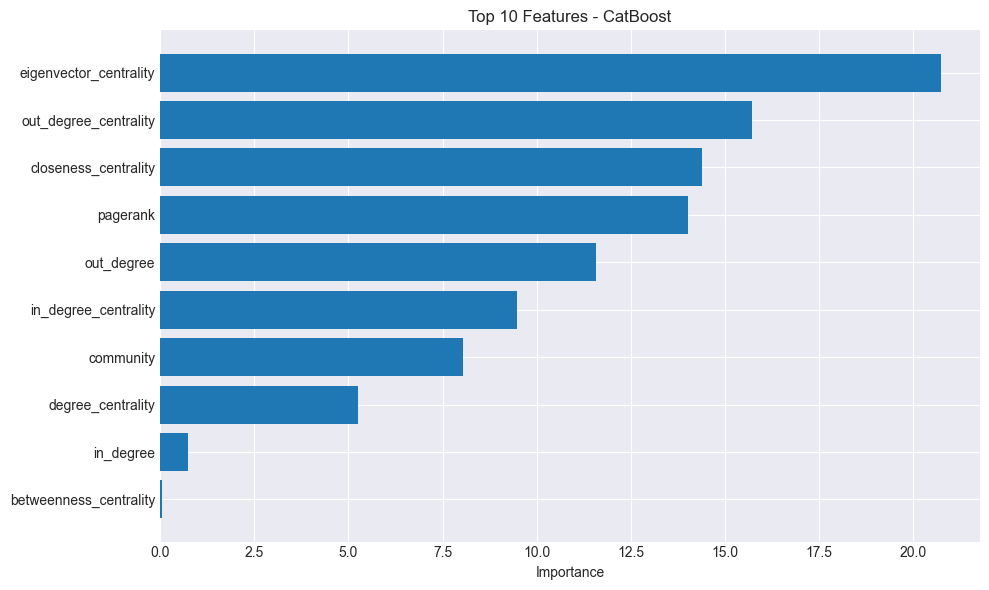

In [18]:
# Feature importance
if hasattr(champion_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': champion_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n🎯 Feature Importance (Top 10):")
    print(importance_df.head(10).to_string(index=False))
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['feature'][:10][::-1], importance_df['importance'][:10][::-1])
    plt.xlabel('Importance')
    plt.title(f'Top 10 Features - {champion_name}')
    plt.tight_layout()
    plt.show()
else:
    print(f"\n⚠️  {champion_name} does not provide feature importances")

### 8.1 SHAP Analysis for Model Explainability

SHAP values provide detailed explanations of how each feature contributes to individual predictions.

In [19]:
# Install and import SHAP
try:
    import shap
    print("✅ SHAP library already installed")
except ImportError:
    print("📦 Installing SHAP library...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap
    print("✅ SHAP library installed successfully")

print(f"   SHAP version: {shap.__version__}")

✅ SHAP library already installed
   SHAP version: 0.49.1


In [20]:
# Create SHAP explainer
print("🔍 Initializing SHAP explainer...")
print(f"   Model type: {champion_name}")
print(f"   Using TreeExplainer for tree-based model")

# Use TreeExplainer for tree-based models (XGBoost, LightGBM, CatBoost, RandomForest)
explainer = shap.TreeExplainer(champion_model)

# Calculate SHAP values on test set (use subset for faster computation)
sample_size = min(500, len(X_test_scaled))
X_test_sample = X_test_scaled[:sample_size]
print(f"\n⏳ Calculating SHAP values for {sample_size} test samples...")

shap_values = explainer.shap_values(X_test_sample)

# For binary classification, some models return list of arrays
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # Get SHAP values for positive class

print(f"✅ SHAP values computed")
print(f"   Shape: {shap_values.shape}")

🔍 Initializing SHAP explainer...
   Model type: CatBoost
   Using TreeExplainer for tree-based model

⏳ Calculating SHAP values for 500 test samples...
✅ SHAP values computed
   Shape: (500, 11)
✅ SHAP values computed
   Shape: (500, 11)



📊 SHAP Summary Plot (Feature Importance)



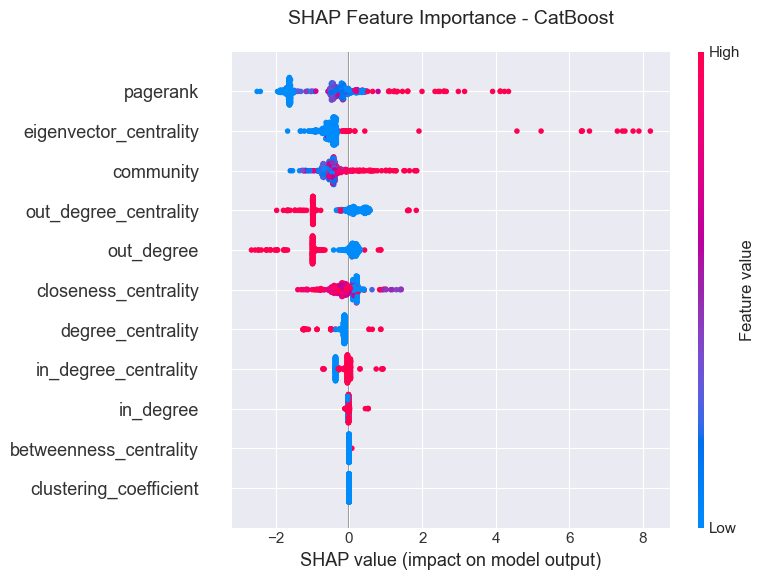

💡 Interpretation:
   - Features are ranked by importance (top to bottom)
   - Each dot represents a sample
   - Red = high feature value, Blue = low feature value
   - Horizontal position shows impact on prediction


In [21]:
# SHAP Summary Plot - Feature Importance
print("\n📊 SHAP Summary Plot (Feature Importance)\n")

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test_sample, 
    feature_names=feature_cols,
    show=False
)
plt.title(f'SHAP Feature Importance - {champion_name}', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("💡 Interpretation:")
print("   - Features are ranked by importance (top to bottom)")
print("   - Each dot represents a sample")
print("   - Red = high feature value, Blue = low feature value")
print("   - Horizontal position shows impact on prediction")


📊 SHAP Bar Plot (Mean Feature Impact)



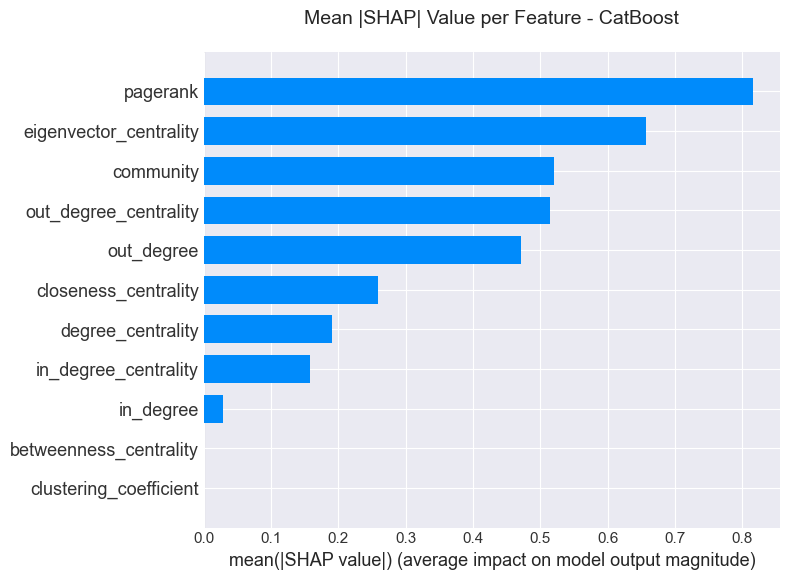

💡 Interpretation:
   - Shows average absolute impact of each feature
   - Higher values = more important for predictions


In [22]:
# SHAP Bar Plot - Mean Absolute SHAP Values
print("\n📊 SHAP Bar Plot (Mean Feature Impact)\n")

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, 
    X_test_sample, 
    feature_names=feature_cols,
    plot_type="bar",
    show=False
)
plt.title(f'Mean |SHAP| Value per Feature - {champion_name}', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("💡 Interpretation:")
print("   - Shows average absolute impact of each feature")
print("   - Higher values = more important for predictions")


📊 SHAP Dependence Plots (Top 3 Features)



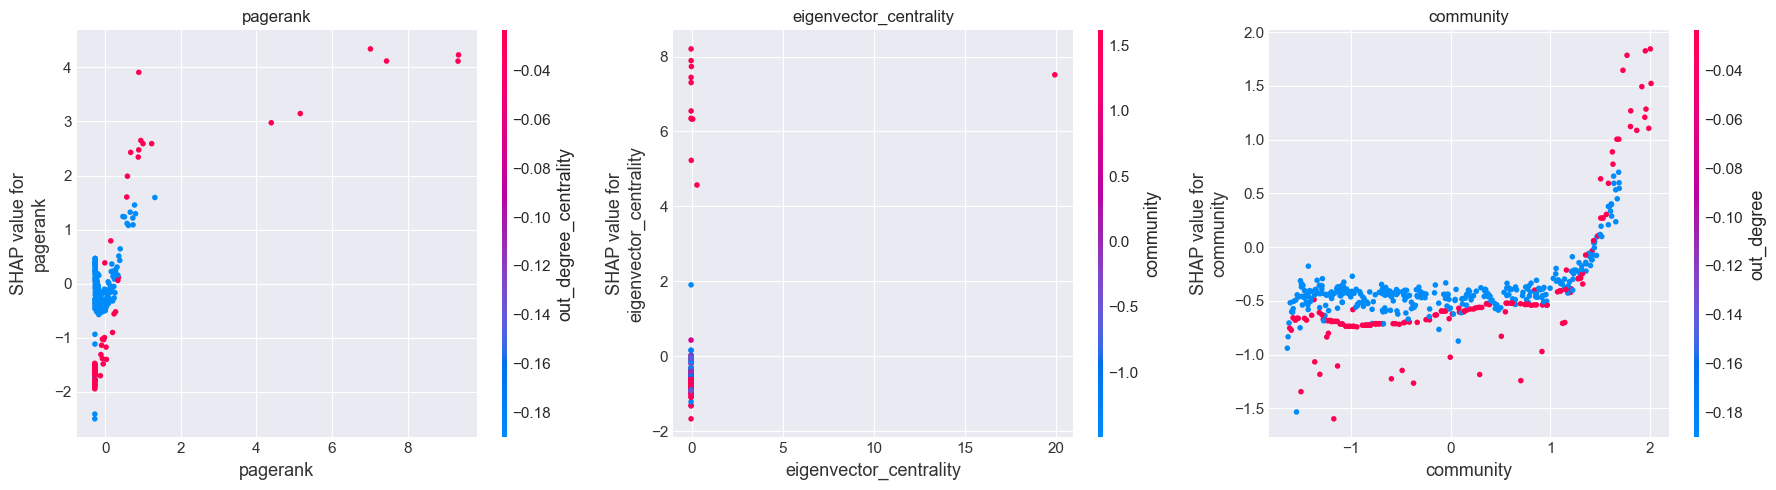

💡 Interpretation:
   - Shows how feature values affect SHAP values (predictions)
   - Color represents interaction with another feature
   - Reveals non-linear relationships and interactions

   Top 3 features: pagerank, eigenvector_centrality, community


In [23]:
# SHAP Dependence Plots - Top 3 Features
print("\n📊 SHAP Dependence Plots (Top 3 Features)\n")

# Get top 3 most important features
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features_idx = np.argsort(mean_abs_shap)[-3:][::-1]
top_features = [feature_cols[i] for i in top_features_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (feat_idx, feat_name) in enumerate(zip(top_features_idx, top_features)):
    plt.sca(axes[idx])
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_test_sample,
        feature_names=feature_cols,
        show=False,
        ax=axes[idx]
    )
    axes[idx].set_title(f'{feat_name}', fontsize=12)

plt.tight_layout()
plt.show()

print("💡 Interpretation:")
print("   - Shows how feature values affect SHAP values (predictions)")
print("   - Color represents interaction with another feature")
print("   - Reveals non-linear relationships and interactions")
print(f"\n   Top 3 features: {', '.join(top_features)}")


📊 SHAP Force Plots (Individual Prediction Explanations)

🚨 Example 1: Suspicious Account (index 8)


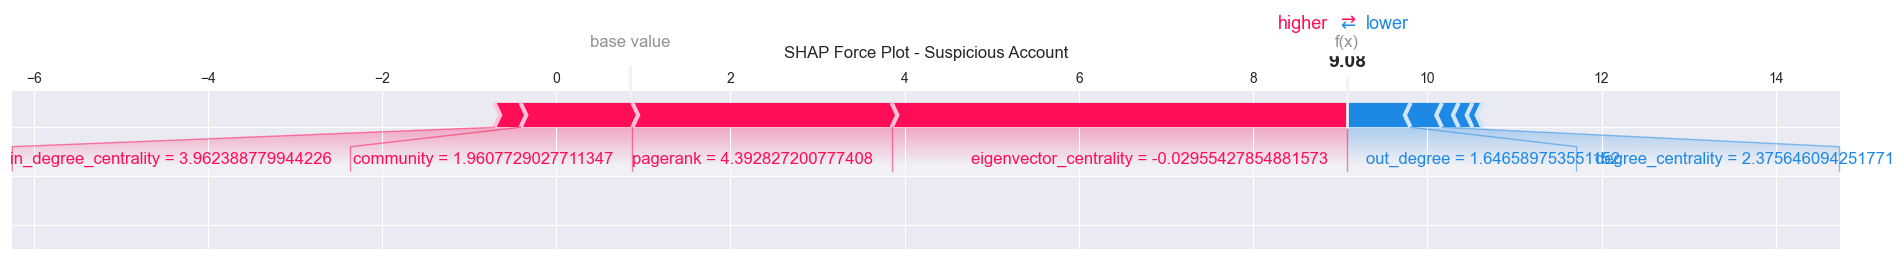


✅ Example 2: Normal Account (index 0)


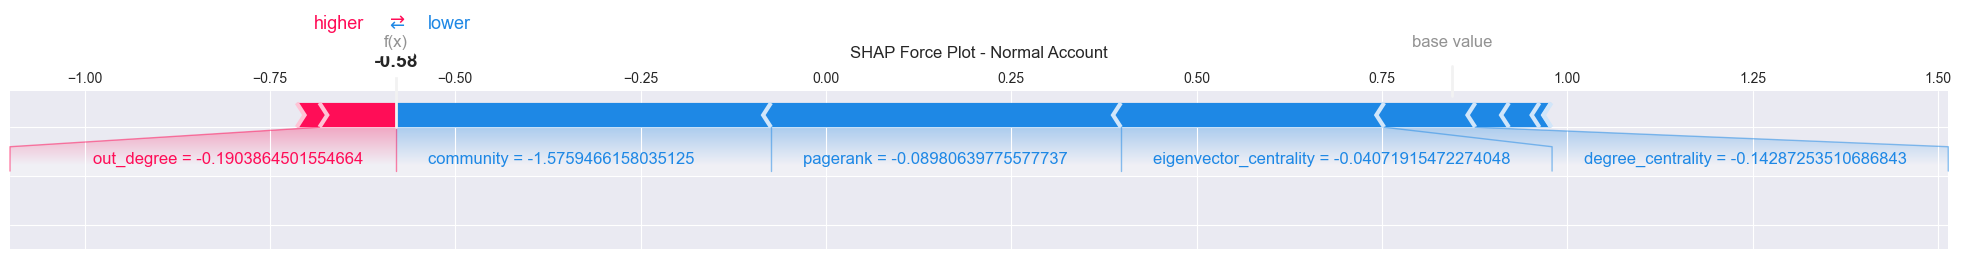


💡 Interpretation:
   - Base value = average model output
   - Red features push prediction higher (toward suspicious)
   - Blue features push prediction lower (toward normal)
   - Feature values and contributions shown on plot


In [24]:
# SHAP Force Plot - Individual Predictions
print("\n📊 SHAP Force Plots (Individual Prediction Explanations)\n")

# Select 2 examples: 1 suspicious, 1 normal
test_indices = list(range(len(X_test_sample)))
y_test_sample = y_test.iloc[:sample_size].values

suspicious_idx = [i for i, label in enumerate(y_test_sample) if label == 1][0]
normal_idx = [i for i, label in enumerate(y_test_sample) if label == 0][0]

print(f"🚨 Example 1: Suspicious Account (index {suspicious_idx})")
shap.force_plot(
    explainer.expected_value,
    shap_values[suspicious_idx],
    X_test_sample[suspicious_idx],
    feature_names=feature_cols,
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot - Suspicious Account', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

print(f"\n✅ Example 2: Normal Account (index {normal_idx})")
shap.force_plot(
    explainer.expected_value,
    shap_values[normal_idx],
    X_test_sample[normal_idx],
    feature_names=feature_cols,
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot - Normal Account', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("   - Base value = average model output")
print("   - Red features push prediction higher (toward suspicious)")
print("   - Blue features push prediction lower (toward normal)")
print("   - Feature values and contributions shown on plot")


📊 SHAP Waterfall Plots (Detailed Breakdown)

🚨 Suspicious Account Breakdown:

✅ Normal Account Breakdown:


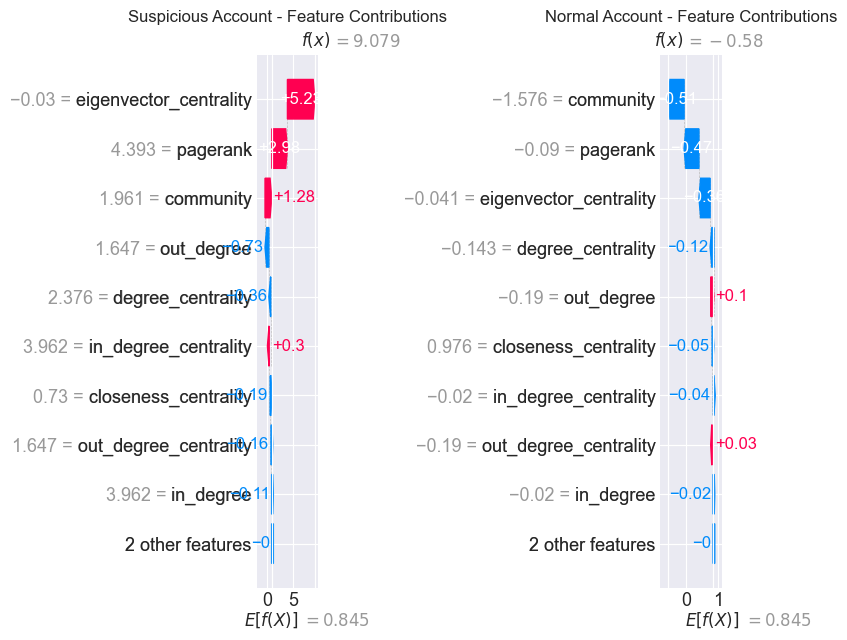


💡 Interpretation:
   - Start from base value (E[f(x)])
   - Each bar shows how a feature changes the prediction
   - Final value = model's prediction for this sample
   - Top features have the largest impact


In [25]:
# SHAP Waterfall Plot - Detailed Feature Contributions
print("\n📊 SHAP Waterfall Plots (Detailed Breakdown)\n")

# Create SHAP Explanation objects for waterfall plots
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value if isinstance(explainer.expected_value, (int, float)) else explainer.expected_value[1],
    data=X_test_sample,
    feature_names=feature_cols
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

print(f"🚨 Suspicious Account Breakdown:")
plt.sca(axes[0])
shap.waterfall_plot(shap_explanation[suspicious_idx], show=False)
axes[0].set_title('Suspicious Account - Feature Contributions', fontsize=12)

print(f"\n✅ Normal Account Breakdown:")
plt.sca(axes[1])
shap.waterfall_plot(shap_explanation[normal_idx], show=False)
axes[1].set_title('Normal Account - Feature Contributions', fontsize=12)

plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("   - Start from base value (E[f(x)])")
print("   - Each bar shows how a feature changes the prediction")
print("   - Final value = model's prediction for this sample")
print("   - Top features have the largest impact")

In [26]:
# SHAP Feature Interaction Analysis
print("\n📊 SHAP Feature Interactions\n")

# Calculate mean absolute SHAP values for ranking
mean_abs_shap_values = np.abs(shap_values).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': mean_abs_shap_values
}).sort_values('mean_abs_shap', ascending=False)

print("🎯 Top 10 Features by SHAP Importance:")
print(shap_importance_df.head(10).to_string(index=False))

# Compare SHAP vs Model Feature Importance
if hasattr(champion_model, 'feature_importances_'):
    comparison_df = pd.DataFrame({
        'feature': feature_cols,
        'model_importance': champion_model.feature_importances_,
        'shap_importance': mean_abs_shap_values
    }).sort_values('shap_importance', ascending=False)
    
    print("\n📊 SHAP vs Model Feature Importance (Top 5):")
    print(comparison_df.head(5)[['feature', 'model_importance', 'shap_importance']].to_string(index=False))
    
    # Correlation between methods
    correlation = comparison_df['model_importance'].corr(comparison_df['shap_importance'])
    print(f"\n🔗 Correlation between methods: {correlation:.3f}")

print("\n✅ SHAP Analysis Complete")
print("\n💡 Key Insights:")
print("   - SHAP provides model-agnostic feature importance")
print("   - Shows both magnitude and direction of feature impacts")
print("   - Reveals feature interactions and non-linear effects")
print("   - Enables individual prediction explanations for transparency")


📊 SHAP Feature Interactions

🎯 Top 10 Features by SHAP Importance:
               feature  mean_abs_shap
              pagerank       0.815376
eigenvector_centrality       0.657000
             community       0.519905
 out_degree_centrality       0.513793
            out_degree       0.471650
  closeness_centrality       0.258725
     degree_centrality       0.190385
  in_degree_centrality       0.157269
             in_degree       0.028500
betweenness_centrality       0.000722

📊 SHAP vs Model Feature Importance (Top 5):
               feature  model_importance  shap_importance
              pagerank         14.025392         0.815376
eigenvector_centrality         20.744576         0.657000
             community          8.031842         0.519905
 out_degree_centrality         15.729936         0.513793
            out_degree         11.585238         0.471650

🔗 Correlation between methods: 0.820

✅ SHAP Analysis Complete

💡 Key Insights:
   - SHAP provides model-agnostic featur

## 9. Save Model Artifacts

In [27]:
# Prepare output directory
import os
os.makedirs(CONFIG['model_output_dir'], exist_ok=True)

# Generate filename-safe model name
model_name_safe = champion_name.lower().replace(' ', '_')
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# File paths
model_path = f"{CONFIG['model_output_dir']}/network_analysis_{model_name_safe}_model.pkl"
scaler_path = f"{CONFIG['model_output_dir']}/network_analysis_{model_name_safe}_scaler.pkl"
metadata_path = f"{CONFIG['model_output_dir']}/network_analysis_{model_name_safe}_metadata.json"

# Save model
with open(model_path, 'wb') as f:
    pickle.dump(champion_model, f)
print(f"✅ Model saved: {model_path}")

# Save scaler
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✅ Scaler saved: {scaler_path}")

# Save metadata
metadata = {
    'model_info': {
        'name': champion_name,
        'type': 'Network Topology Anomaly Detector',
        'created_at': datetime.now().isoformat(),
        'version': '2.0_clean'
    },
    'config': CONFIG,
    'network_stats': {
        'nodes': G.number_of_nodes(),
        'edges': G.number_of_edges(),
        'density': nx.density(G)
    },
    'training_data': {
        'total_samples': len(df_model),
        'train_samples': len(X_train),
        'test_samples': len(X_test),
        'suspicious_rate': float(y.mean())
    },
    'features': {
        'count': len(feature_cols),
        'list': feature_cols,
        'note': 'Topology only - volume features excluded'
    },
    'performance': {
        'roc_auc': float(df_results.iloc[0]['ROC-AUC']),
        'pr_auc': float(df_results.iloc[0]['PR-AUC']),
        'f1_score': float(df_results.iloc[0]['F1-Score']),
        'precision': float(df_results.iloc[0]['Precision']),
        'recall': float(df_results.iloc[0]['Recall'])
    },
    'all_models': df_results.to_dict('records')
}

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Metadata saved: {metadata_path}")

print(f"\n📦 Model artifacts ready for deployment")

✅ Model saved: ../trained_models//network_analysis_catboost_model.pkl
✅ Scaler saved: ../trained_models//network_analysis_catboost_scaler.pkl
✅ Metadata saved: ../trained_models//network_analysis_catboost_metadata.json

📦 Model artifacts ready for deployment


## 10. Test Predictions on Sample Accounts

Let's test the model on real examples to see how it predicts suspicious accounts based on network topology.

In [31]:
# Select diverse test samples
print("📋 Selecting Test Samples...\n")

# Get 5 suspicious and 5 normal accounts from test set
test_df = df_model.loc[X_test.index].copy()
test_df['prediction_proba'] = champion_model.predict_proba(X_test_scaled)[:, 1]
test_df['prediction'] = champion_model.predict(X_test_scaled)

# Select samples
suspicious_samples = test_df[test_df['is_suspicious'] == 1].sample(n=5, random_state=42)
normal_samples = test_df[test_df['is_suspicious'] == 0].sample(n=5, random_state=42)

test_samples = pd.concat([suspicious_samples, normal_samples]).sort_values('prediction_proba', ascending=False)

print(f"✅ Selected 10 test samples:")
print(f"   - 5 Suspicious accounts (true label)")
print(f"   - 5 Normal accounts (true label)")
print(f"\n   Sorted by prediction probability (high to low)")

📋 Selecting Test Samples...

✅ Selected 10 test samples:
   - 5 Suspicious accounts (true label)
   - 5 Normal accounts (true label)

   Sorted by prediction probability (high to low)


In [32]:
# Display predictions with network features
print("🔍 Test Predictions Analysis\n")
print("="*100)

for idx, row in test_samples.iterrows():
    account_id = row['account']
    true_label = "🚨 Suspicious" if row['is_suspicious'] == 1 else "✅ Normal"
    pred_label = "🚨 Suspicious" if row['prediction'] == 1 else "✅ Normal"
    pred_proba = row['prediction_proba']
    
    # Determine if prediction is correct
    is_correct = "✓" if row['is_suspicious'] == row['prediction'] else "✗"
    
    print(f"\n📊 Account: {account_id}")
    print(f"   True Label:       {true_label}")
    print(f"   Predicted:        {pred_label} ({pred_proba:.1%} confidence)")
    print(f"   Result:           {is_correct} {'CORRECT' if is_correct == '✓' else 'INCORRECT'}")
    print(f"   ")
    print(f"   🔗 Network Features:")
    print(f"      Eigenvector Centrality:  {row['eigenvector_centrality']:.6f}")
    print(f"      In-Degree Centrality:    {row['in_degree_centrality']:.6f}")
    print(f"      Closeness Centrality:    {row['closeness_centrality']:.6f}")
    print(f"      PageRank:                {row['pagerank']:.6f}")
    print(f"      Community:               {int(row['community'])}")
    print(f"      In-Degree:               {int(row['in_degree'])}")
    print(f"      Out-Degree:              {int(row['out_degree'])}")
    print("-"*100)

print("\n" + "="*100)

🔍 Test Predictions Analysis


📊 Account: 7518390314.0
   True Label:       🚨 Suspicious
   Predicted:        🚨 Suspicious (100.0% confidence)
   Result:           ✓ CORRECT
   
   🔗 Network Features:
      Eigenvector Centrality:  0.000000
      In-Degree Centrality:    0.000059
      Closeness Centrality:    0.000059
      PageRank:                0.000038
      Community:               2307
      In-Degree:               17
      Out-Degree:              46
----------------------------------------------------------------------------------------------------

📊 Account: 5173333833.0
   True Label:       🚨 Suspicious
   Predicted:        🚨 Suspicious (100.0% confidence)
   Result:           ✓ CORRECT
   
   🔗 Network Features:
      Eigenvector Centrality:  0.010118
      In-Degree Centrality:    0.000003
      Closeness Centrality:    0.000028
      PageRank:                0.000018
      Community:               4558
      In-Degree:               1
      Out-Degree:              1
--

In [33]:
# Summary statistics
print("\n📈 Prediction Summary Statistics\n")

correct_predictions = (test_samples['is_suspicious'] == test_samples['prediction']).sum()
total_predictions = len(test_samples)
accuracy = correct_predictions / total_predictions

print(f"✅ Accuracy on samples: {correct_predictions}/{total_predictions} ({accuracy:.1%})")
print(f"\n📊 Confidence Distribution:")
print(f"   High confidence (>80%):   {(test_samples['prediction_proba'] > 0.8).sum()} samples")
print(f"   Medium confidence (50-80%): {((test_samples['prediction_proba'] >= 0.5) & (test_samples['prediction_proba'] <= 0.8)).sum()} samples")
print(f"   Low confidence (<50%):    {(test_samples['prediction_proba'] < 0.5).sum()} samples")

print(f"\n🎯 Breakdown by True Label:")
suspicious_correct = ((test_samples['is_suspicious'] == 1) & (test_samples['prediction'] == 1)).sum()
suspicious_total = (test_samples['is_suspicious'] == 1).sum()
normal_correct = ((test_samples['is_suspicious'] == 0) & (test_samples['prediction'] == 0)).sum()
normal_total = (test_samples['is_suspicious'] == 0).sum()

print(f"   Suspicious: {suspicious_correct}/{suspicious_total} correct ({suspicious_correct/suspicious_total:.1%})")
print(f"   Normal:     {normal_correct}/{normal_total} correct ({normal_correct/normal_total:.1%})")


📈 Prediction Summary Statistics

✅ Accuracy on samples: 8/10 (80.0%)

📊 Confidence Distribution:
   High confidence (>80%):   2 samples
   Medium confidence (50-80%): 3 samples
   Low confidence (<50%):    5 samples

🎯 Breakdown by True Label:
   Suspicious: 4/5 correct (80.0%)
   Normal:     4/5 correct (80.0%)


## 11. Future Improvements

**Data Quality:**
- Use ground truth labels from real AML investigations instead of volume-based proxy labels
- Incorporate temporal dynamics (transaction patterns over time windows)

**Feature Engineering:**
- Add temporal network features (evolving centrality, community stability)
- Include transaction metadata (amounts, types, timestamps) as node attributes
- Create graph embeddings (Node2Vec, GraphSAGE) for richer representations

**Model Architecture:**
- Implement Graph Neural Networks (GNN) for end-to-end learning
- Add ensemble methods combining topology + temporal + transaction features
- Use semi-supervised learning to leverage unlabeled data

**Performance:**
- Address class imbalance with advanced techniques (focal loss, cost-sensitive learning)
- Optimize network construction (use sampling for large graphs, parallel processing)
- Implement incremental updates instead of full graph reconstruction

**Production:**
- Add model monitoring and drift detection
- Create explainability tools (SHAP for network features, subgraph explanations)
- Implement A/B testing framework for model updates